In [1]:
# Automobile Price Analysis
# Dataset: Car Price Prediction
# Role: Data Analyst

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the car dataset and remove the extra index column if it exists.
df = pd.read_csv('../data/Clean Data_pakwheels.csv')
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df.head(10)

,Company Name,Model Name,Price,Model Year,Location,Mileage,Engine Type,Engine Capacity,Color,Assembly,Body Type,Transmission Type,Registration Status
0,Toyota,Vitz,2385000,2017,Islamabad,9869,Petrol,1000,Silver,Imported,Hatchback,Automatic,Un-Registered
1,Toyota,Corolla,111000,2019,KPK,11111,Petrol,1300,White,Local,Sedan,Automatic,Registered
2,Suzuki,Alto,1530000,2019,KPK,17500,Petrol,660,White,Local,Hatchback,Automatic,Un-Registered
3,Suzuki,Alto,1650000,2019,Punjab,9600,Petrol,660,White,Local,Hatchback,Manual,Registered
4,Toyota,Corolla,1435000,2010,Islamabad,120000,Petrol,1300,Black,Local,Sedan,Manual,Registered
5,Honda,Civic,3850000,2017,Punjab,22000,Petrol,1500,Black,Local,Sedan,Automatic,Registered
6,Suzuki,Wagon,1440000,2017,Punjab,31000,Petrol,1000,White,Local,Hatchback,Manual,Registered
7,Mitsubishi,Mirage,1425000,2012,Punjab,101000,Petrol,1000,Black,Imported,Hatchback,Automatic,Registered
8,Toyota,Prado,2650000,1998,Punjab,110000,Diesel,3000,Beige,Imported,SUV,Automatic,Registered
9,Honda,Civic,3350000,2017,Punjab,60000,Petrol,1800,White,Local,Sedan,Automatic,Registered


In [4]:
df.shape

(46022, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46022 entries, 0 to 46021
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Company Name         46022 non-null  object
 1   Model Name           46022 non-null  object
 2   Price                46022 non-null  int64 
 3   Model Year           46022 non-null  int64 
 4   Location             46022 non-null  object
 5   Mileage              46022 non-null  int64 
 6   Engine Type          46022 non-null  object
 7   Engine Capacity      46022 non-null  int64 
 8   Color                46022 non-null  object
 9   Assembly             46022 non-null  object
 10  Body Type            46022 non-null  object
 11  Transmission Type    46022 non-null  object
 12  Registration Status  46022 non-null  object
dtypes: int64(4), object(9)
memory usage: 4.6+ MB


In [6]:
df.duplicated().sum()

np.int64(815)

In [7]:
dup = df[df.duplicated(keep=False)]          # original + duplicate dono
dup_sorted = dup.sort_values(list(df.columns))
dup_sorted.head(20)

,Company Name,Model Name,Price,Model Year,Location,Mileage,Engine Type,Engine Capacity,Color,Assembly,Body Type,Transmission Type,Registration Status
2703,Audi,A3,6900000,2017,Islamabad,40000,Petrol,1800,White,Local,Sedan,Automatic,Registered
2725,Audi,A3,6900000,2017,Islamabad,40000,Petrol,1800,White,Local,Sedan,Automatic,Registered
10356,Audi,A3,7000000,2019,Punjab,16000,Petrol,1200,Black,Imported,Sedan,Automatic,Registered
32770,Audi,A3,7000000,2019,Punjab,16000,Petrol,1200,Black,Imported,Sedan,Automatic,Registered
24576,Daihatsu,Cast,1150000,2016,Punjab,32000,Petrol,660,Blue,Imported,Hatchback,Automatic,Registered
26313,Daihatsu,Cast,1150000,2016,Punjab,32000,Petrol,660,Blue,Imported,Hatchback,Automatic,Registered
5893,Daihatsu,Cuore,430000,2003,Punjab,100000,Petrol,800,White,Local,Hatchback,Manual,Registered
7940,Daihatsu,Cuore,430000,2003,Punjab,100000,Petrol,800,White,Local,Hatchback,Manual,Registered
44515,Daihatsu,Cuore,450000,2004,Sindh,150000,Petrol,800,Navy,Local,Hatchback,Manual,Registered
44654,Daihatsu,Cuore,450000,2004,Sindh,150000,Petrol,800,Navy,Local,Hatchback,Manual,Registered


In [8]:
df = df.drop_duplicates()

In [9]:
df.describe()

,Price,Model Year,Mileage,Engine Capacity
count,4.520700e+04,45207.000000,45207.000000,45207.000000
mean,2.021203e+06,2011.017121,91121.327294,1315.379499
std,2.957473e+06,6.413954,63834.680164,616.927131
min,1.110000e+05,1990.000000,1.000000,16.000000
25%,8.500000e+05,2007.000000,49000.000000,1000.000000
50%,1.450000e+06,2013.000000,80000.000000,1300.000000
75%,2.300000e+06,2016.000000,120000.000000,1500.000000
max,7.750000e+07,2019.000000,999999.000000,6600.000000


In [10]:
df.columns

Index(['Company Name', 'Model Name', 'Price', 'Model Year', 'Location',
       'Mileage', 'Engine Type', 'Engine Capacity', 'Color', 'Assembly',
       'Body Type', 'Transmission Type', 'Registration Status'],
      dtype='object')

In [11]:
# check missing values

df.isnull().sum()

# Observation:
# No major missing values are present in the dataset.

Company Name           0
Model Name             0
Price                  0
Model Year             0
Location               0
Mileage                0
Engine Type            0
Engine Capacity        0
Color                  0
Assembly               0
Body Type              0
Transmission Type      0
Registration Status    0
dtype: int64

In [12]:
# Count unique values in each column to understand how many categories we have.
unique_values = df.nunique()
print(unique_values)

Company Name             31
Model Name              196
Price                  1419
Model Year               30
Location                  6
Mileage                5573
Engine Type               3
Engine Capacity          75
Color                    24
Assembly                  2
Body Type                 6
Transmission Type         2
Registration Status       2
dtype: int64


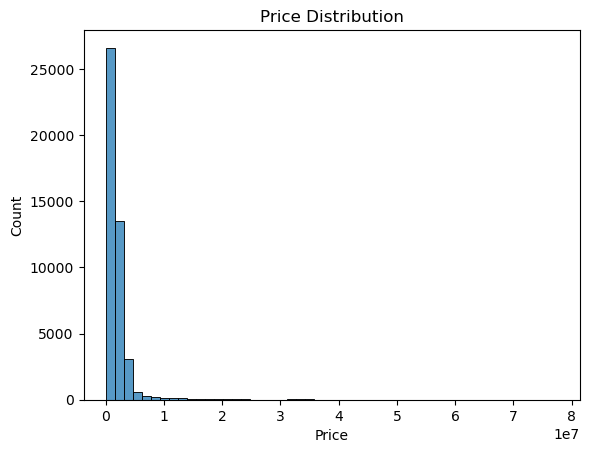

In [13]:
# distribution analysis

sns.histplot(df['Price'], bins=50)
plt.title("Price Distribution")
plt.show()

<Axes: xlabel='Price'>

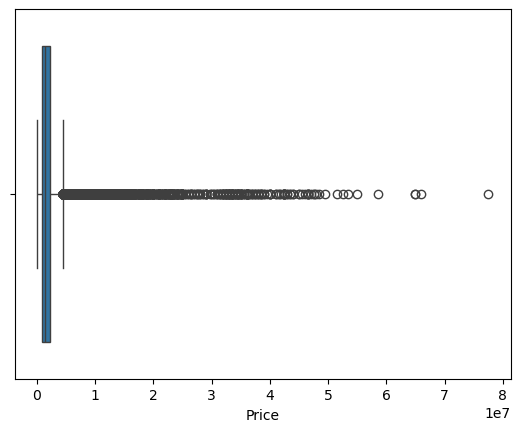

In [14]:
import seaborn as sns

sns.boxplot(x=df['Price'])

In [15]:
# remove outliers from Price (IQR method)
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

rows_before = len(df)
df = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)].copy()
df.reset_index(drop=True, inplace=True)
rows_after = len(df)

print(f"Rows before outlier removal: {rows_before}")
print(f"Rows after outlier removal: {rows_after}")
print(f"Outliers removed: {rows_before - rows_after}")

Rows before outlier removal: 45207
Rows after outlier removal: 43023
Outliers removed: 2184


In [16]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

# 1. Cars with higher engine capacity generally have higher prices.

# 2. Automatic transmission cars are slightly more expensive than manual cars.

# 3. Cars with lower mileage tend to have higher prices.

# 4. Newer model year cars have higher price values.

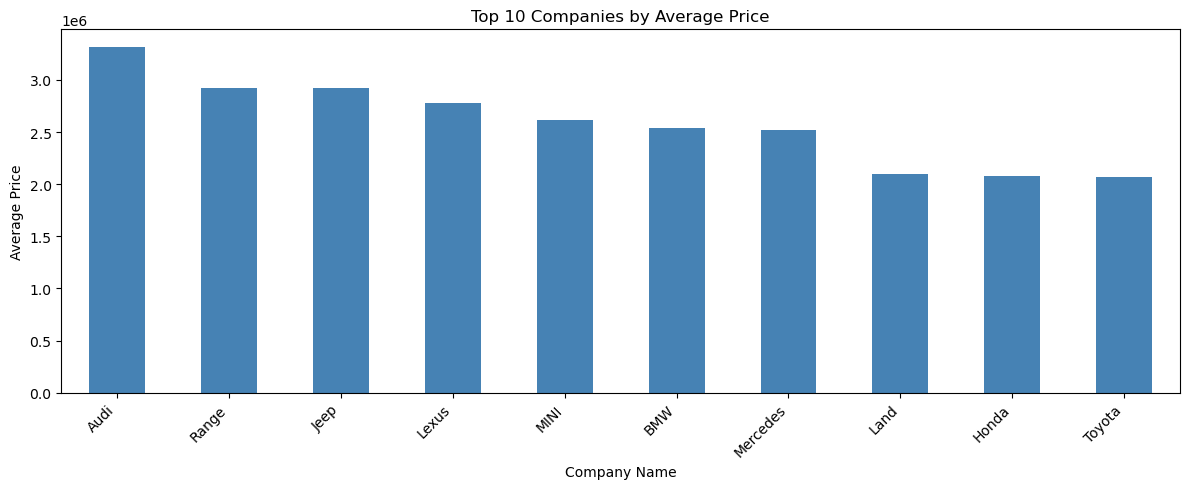

In [17]:
# Plot the top 10 companies by average price to show which brands are more expensive.
# konsa brand high end segment me aa raha hai 
top_companies = df.groupby('Company Name')['Price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
top_companies.plot(kind='bar', color='steelblue')
plt.title('Top 10 Companies by Average Price')
plt.xlabel('Company Name')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
# Show how many cars we have for each company.--->konse brand ke kitne cars available hai
df['Company Name'].value_counts()

Company Name
Suzuki        15552
Toyota        13888
Honda          8898
Daihatsu       2242
Nissan          564
Mitsubishi      489
Hyundai         356
Mercedes        288
FAW             187
Mazda           118
BMW              84
United           63
KIA              60
Subaru           57
Daewoo           48
Chevrolet        40
Lexus            27
SsangYong        13
Audi             10
DFSK              8
Chery             8
Land              7
Jeep              5
Fiat              4
MINI              3
Range             2
Adam              1
Volvo             1
Name: count, dtype: int64

In [19]:
# Show how many cars come from each model year.--->konse model kitne popular hai konse model market me kitne chal rahe hai 
df['Model Year'].value_counts()

Model Year
2015    3621
2017    3495
2016    3450
2014    3289
2018    3054
2019    2564
2007    2543
2013    2341
2012    2185
2011    2024
2006    2021
2005    1661
2010    1643
2008    1585
2004    1171
2009    1089
2003     811
2002     544
2001     506
2000     449
1996     439
1997     401
1998     398
1999     375
1995     337
1994     247
1993     241
1992     210
1990     178
1991     151
Name: count, dtype: int64

In [20]:
# Show how many cars are listed in each location.-->konse city me car jyada hai ya demand jyada hai 
df['Location'].value_counts()

Location
Punjab         23192
Sindh           8129
Islamabad       6021
KPK             5128
Balochistan      311
Kashmir          242
Name: count, dtype: int64

In [21]:
# Show how mileage values are distributed across the dataset.--->konse mileage ke cars jyada hai market me
#price anlaysis me mileage ek imp factor hai q ki kum mileage ki gaadi jyada nhi bikti
df['Mileage'].value_counts()

Mileage
100000    2122
150000    1220
80000      964
200000     859
120000     849
          ... 
264000       1
41150        1
11549        1
106389       1
42746        1
Name: count, Length: 5362, dtype: int64

In [22]:
# Show how many cars we have for each engine type.-->konse type ke engine jyada hai market me
df['Engine Type'].value_counts()

Engine Type
Petrol    40944
Hybrid     1243
Diesel      836
Name: count, dtype: int64

In [33]:
# Clean invalid color entries and show final color distribution.
invalid_color_count = (df['Color'] == 'Assembly').sum()
df.loc[df['Color'] == 'Assembly', 'Color'] = 'Unlisted'

print(f"Invalid 'Assembly' entries moved from Color to 'Unlisted': {invalid_color_count}")
df['Color'].value_counts()

Invalid 'Assembly' entries moved from Color to 'Unlisted': 0


Color
White        16221
Silver        7713
Black         5226
Grey          4869
Blue          2056
Unlisted      1388
Gold           975
Maroon         892
Red            792
Green          748
Beige          563
Burgundy       293
Brown          255
Turquoise      227
Bronze         204
Pink           191
Navy           111
Yellow          94
Indigo          83
Purple          82
Orange          37
Magenta          2
Wine             1
Name: count, dtype: int64

In [24]:
# Show how many cars are local or imported.-->imported cars mehngi hoti hai 
df['Assembly'].value_counts()

Assembly
Local       30133
Imported    12890
Name: count, dtype: int64

In [25]:
# Show the body type distribution to see which car shapes are most common.
df['Body Type'].value_counts()

Body Type
Hatchback     21122
Sedan         18155
Mini Van       1178
SUV            1055
Cross Over      855
Van             658
Name: count, dtype: int64

In [26]:
# Show how many cars use manual versus automatic transmission.
df['Transmission Type'].value_counts()

Transmission Type
Manual       24052
Automatic    18971
Name: count, dtype: int64

In [27]:
# Show how many cars are registered or unregistered.
df['Registration Status'].value_counts()

Registration Status
Registered       40222
Un-Registered     2801
Name: count, dtype: int64

In [36]:
# One-Hot Encoding on selected 7 categorical columns.
# We encode text columns so ML models can use numeric input.
# Price is the target variable and is not encoded.
columns_to_encode = ['Company Name', 'Model Name', 'Location', 'Engine Type', 'Body Type', 'Transmission Type', 'Assembly']
X = pd.get_dummies(df, columns=columns_to_encode)

print('Encoded shape:', X.shape)
X.iloc[:, :10].head()

Encoded shape: (43023, 233)


,Price,Model Year,Mileage,Engine Capacity,Color,Registration Status,Company Name_Adam,Company Name_Audi,Company Name_BMW,Company Name_Chery
0,2385000,2017,9869,1000,Silver,Un-Registered,False,False,False,False
1,111000,2019,11111,1300,White,Registered,False,False,False,False
2,1530000,2019,17500,660,White,Un-Registered,False,False,False,False
3,1650000,2019,9600,660,White,Registered,False,False,False,False
4,1435000,2010,120000,1300,Black,Registered,False,False,False,False
